In [1]:
!pip install -U "protobuf<5" --force-reinstall --quiet
!pip install -U tensorflow --quiet  # optional, ensures clean rebuild
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide CUDA backend warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 9.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.3.0 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have proto

In [2]:
# LIBRARIES
import os
import random
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.utils import shuffle
from skimage import color
from pathlib import Path
import kagglehub
from tensorflow.keras.layers import Input
import imageio
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error

In [3]:
# DATASET
dataset_path = Path(kagglehub.dataset_download("akash2sharma/tiny-imagenet"))
tiny_path = dataset_path / "tiny-imagenet-200"
print("Dataset downloaded to:", tiny_path)

Dataset downloaded to: /kaggle/input/tiny-imagenet/tiny-imagenet-200


In [4]:
# PER-CLASS SAMPLE + PER-CLASS 80/20 SPLIT
def sample_subset_split(source_dir, num_classes, samples_per_class, seed=42):
    random.seed(seed)
    train_dir = source_dir / "train"
    all_classes = sorted([c for c in train_dir.iterdir() if c.is_dir()])
    chosen_classes = random.sample(all_classes, num_classes)
    train_paths = []
    val_paths = []
    
    for cls in chosen_classes:
        img_dir = cls / "images"
        imgs = list(img_dir.glob("*.JPEG"))
        imgs = random.sample(imgs, min(samples_per_class, len(imgs)))
        split = int(0.8 * len(imgs))
        cls_train = imgs[:split]
        cls_val = imgs[split:]
        train_paths.extend(cls_train)
        val_paths.extend(cls_val)
    return train_paths, val_paths
    
train_paths, val_paths = sample_subset_split(tiny_path, num_classes=100, samples_per_class=300)
print(f"Train images: {len(train_paths)}, Val images: {len(val_paths)}")

# DATA LOADER
IMG_SIZE = 64
def load_and_preprocess_image(img_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    lab = color.rgb2lab(img).astype("float32")
    L = lab[:, :, 0] / 100.0      
    ab = lab[:, :, 1:] / 128.0     
    return L[..., np.newaxis], ab

def create_dataset(paths):
    Ls, abs_ = [], []
    for p in paths:
        L, ab = load_and_preprocess_image(p)
        Ls.append(L)
        abs_.append(ab)
    return np.array(Ls), np.array(abs_)

X_train, Y_train = create_dataset(train_paths)
X_val, Y_val = create_dataset(val_paths)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train images: 24000, Val images: 6000
Train: (24000, 64, 64, 1), Val: (6000, 64, 64, 1)


In [5]:
# U-NET
def unet_model(output_channels=2):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    bn = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    bn = layers.Conv2D(512, 3, activation='relu', padding='same')(bn)

    # Decoder
    u1 = layers.UpSampling2D((2, 2))(bn)
    u1 = layers.concatenate([u1, c3])
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D((2, 2))(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2)

    u3 = layers.UpSampling2D((2, 2))(c5)
    u3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(u3)

    # Tanh value for each pixel
    outputs = layers.Conv2D(output_channels, 1, activation='tanh')(c6)
    return models.Model(inputs, outputs)

In [6]:
# TRAIN
model = unet_model(output_channels=2)
model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=70,
    batch_size=32,
    verbose=1
)

I0000 00:00:1765012227.651552      47 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765012227.652215      47 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/70
  1/750 ━━━━━━━━━━━━━━━━━━━━ 3:12:17 15s/step - loss: 0.0201

I0000 00:00:1765012246.524465     125 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


750/750 ━━━━━━━━━━━━━━━━━━━━ 78s 83ms/step - loss: 0.0129 - val_loss: 0.0127
Epoch 2/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 60s 80ms/step - loss: 0.0125 - val_loss: 0.0125
Epoch 3/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - loss: 0.0123 - val_loss: 0.0122
Epoch 4/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - loss: 0.0121 - val_loss: 0.0120
Epoch 5/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - loss: 0.0118 - val_loss: 0.0119
Epoch 6/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - loss: 0.0117 - val_loss: 0.0116
Epoch 7/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - loss: 0.0116 - val_loss: 0.0117
Epoch 8/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - loss: 0.0115 - val_loss: 0.0117
Epoch 9/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - loss: 0.0115 - val_loss: 0.0116
Epoch 10/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - loss: 0.0113 - val_loss: 0.0115
Epoch 11/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 61s 81ms/step - loss: 0.0113 - val_loss: 0.0113
Epoch 12/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 

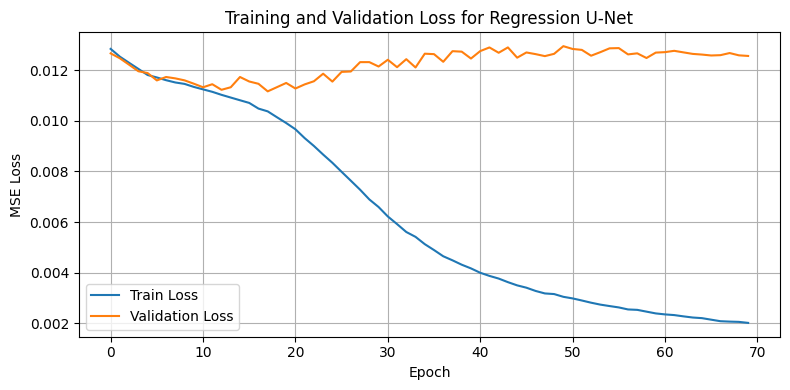

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss for Regression U-Net')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


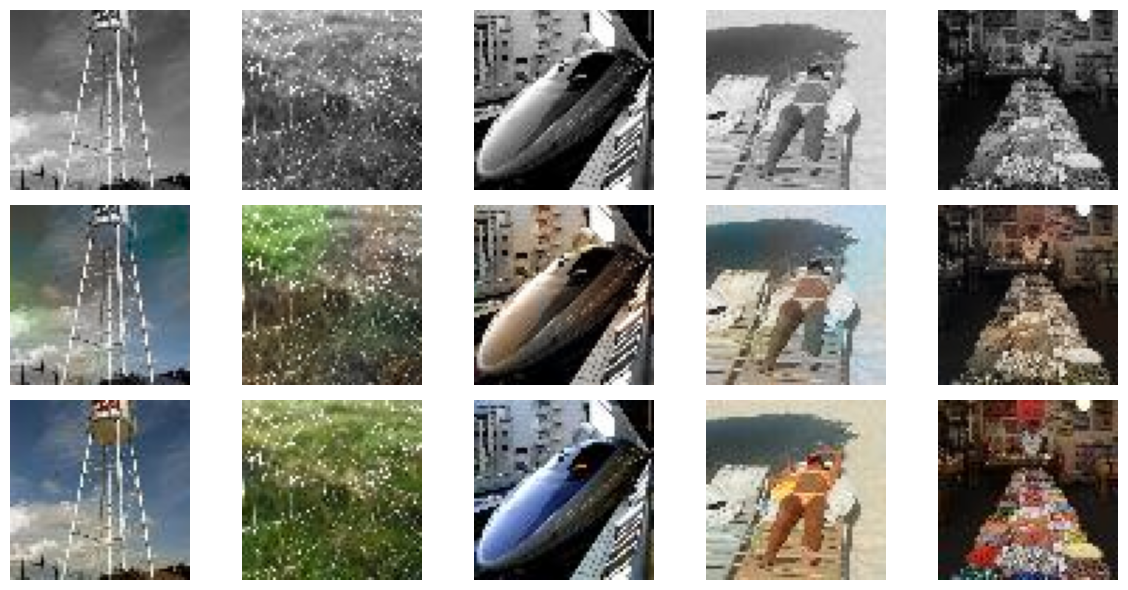

In [11]:
# PREDICT ON TEST SET
random.seed(888)
np.random.seed(888)

# Lab to RGB
def lab_to_rgb(L, ab):
    L = L * 100
    ab = ab * 128
    lab = np.concatenate((L, ab), axis=-1)
    rgb = np.clip(color.lab2rgb(lab), 0, 1)
    return rgb

num_samples = 5
idxs = random.sample(range(len(X_val)), num_samples)

preds = model.predict(X_val[idxs])

plt.figure(figsize=(12, 6))
for i, idx in enumerate(idxs):
    L = X_val[idx]
    ab_pred = preds[i]
    ab_true = Y_val[idx]
    colorized_pred = lab_to_rgb(L, ab_pred)
    colorized_true = lab_to_rgb(L, ab_true)
    gray = np.repeat(L, 3, axis=-1)

    plt.subplot(3, num_samples, i + 1)
    plt.imshow(gray)
    plt.axis('off')
    if i == 0:
        plt.ylabel("Input", fontsize=12)

    plt.subplot(3, num_samples, i + 1 + num_samples)
    plt.imshow(colorized_pred)
    plt.axis('off')
    if i == 0:
        plt.ylabel("Predicted", fontsize=12)

    plt.subplot(3, num_samples, i + 1 + 2*num_samples)
    plt.imshow(colorized_true)
    plt.axis('off')
    if i == 0:
        plt.ylabel("Ground Truth", fontsize=12)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


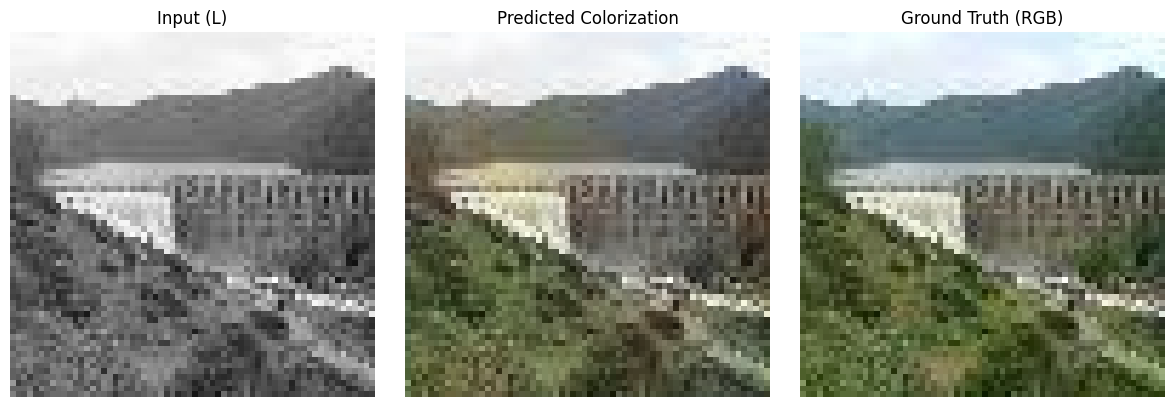

In [9]:
# PREDICT ON ONE IMAGE OF CHOICE
img_path = "/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1018.JPEG"

# Load image
rgb = cv2.imread(img_path)[:, :, ::-1]     
rgb = cv2.resize(rgb, (64, 64))            
rgb_norm = rgb / 255.0

# Preprocess image
lab = color.rgb2lab(rgb_norm)            
L = lab[:, :, 0:1] / 100.0                
ab_true = lab[:, :, 1:] / 128.0            
L_batch = np.expand_dims(L, axis=0)

# Predict
ab_pred = model.predict(L_batch)[0]       

# Convert to RGB
def lab_to_rgb(L, ab):
    L2 = L * 100
    ab2 = ab * 128
    lab = np.concatenate((L2, ab2), axis=-1)
    rgb = color.lab2rgb(lab)
    return np.clip(rgb, 0, 1)
    
colorized_pred = lab_to_rgb(L, ab_pred)
colorized_true = lab_to_rgb(L, ab_true)
gray = np.repeat(L, 3, axis=-1)

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray)
plt.axis("off")
plt.title("Input (L)")

plt.subplot(1, 3, 2)
plt.imshow(colorized_pred)
plt.axis("off")
plt.title("Predicted Colorization")

plt.subplot(1, 3, 3)
plt.imshow(colorized_true)
plt.axis("off")
plt.title("Ground Truth (RGB)")

plt.tight_layout()
plt.show()

In [21]:
# 1 "/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1018.JPEG"
# 2 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_0.JPEG'
# 3 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1078.JPEG'
# 4 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1103.JPEG'
# 5 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1129.JPEG'
# 6 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1186.JPEG'
# 7 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1202.JPEG'
# 8 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_132.JPEG'
# 9 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1314.JPEG'
# 10 '/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_2005.JPEG'

'/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_1023.JPEG'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Saved images to: single_output
MSE:  0.001702
SSIM: 0.949290


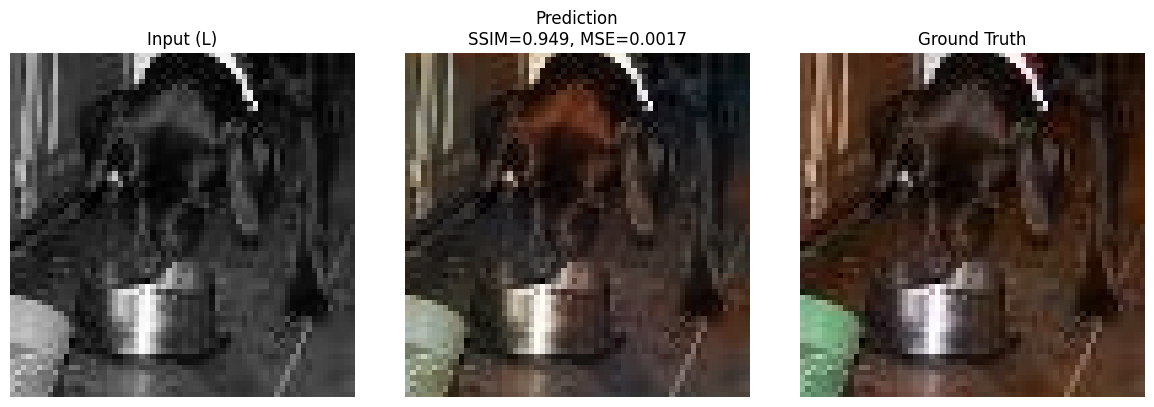

In [63]:
# PREDICT ON ONE IMAGE OF CHOICE
img_path = "/kaggle/input/tiny-imagenet/tiny-imagenet-200/test/images/test_2005.JPEG"

# Load image
rgb = cv2.imread(img_path)[:, :, ::-1]
rgb = cv2.resize(rgb, (64, 64))
rgb_norm = rgb / 255.0

# Preprocess image
lab = color.rgb2lab(rgb_norm)
L = lab[:, :, 0:1] / 100.0
ab_true = lab[:, :, 1:] / 128.0
L_batch = np.expand_dims(L, axis=0)

# Predict
ab_pred = model.predict(L_batch)[0]

# Convert to RGB
def lab_to_rgb(L, ab):
    L2 = L * 100
    ab2 = ab * 128
    lab = np.concatenate((L2, ab2), axis=-1)
    rgb = color.lab2rgb(lab)
    return np.clip(rgb, 0, 1)
colorized_pred = lab_to_rgb(L, ab_pred)
colorized_true = lab_to_rgb(L, ab_true)
gray = np.repeat(L, 3, axis=-1)

# SAVE IMAGES 
out_dir = "single_output"
os.makedirs(out_dir, exist_ok=True)
imageio.imwrite(f"{out_dir}/grayscale10.png", (gray * 255).astype(np.uint8))
imageio.imwrite(f"{out_dir}/predicted10.png", (colorized_pred * 255).astype(np.uint8))
imageio.imwrite(f"{out_dir}/ground_truth10.png", (colorized_true * 255).astype(np.uint8))
print("Saved images to:", out_dir)

# COMPUTE SSIM & MSE
mse_val = mean_squared_error(colorized_true.flatten(), colorized_pred.flatten())
ssim_val = ssim(colorized_true, colorized_pred, channel_axis=2, data_range=1.0)
print(f"MSE:  {mse_val:.6f}")
print(f"SSIM: {ssim_val:.6f}")

# PLOT
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray)
plt.axis("off")
plt.title("Input (L)")

plt.subplot(1, 3, 2)
plt.imshow(colorized_pred)
plt.axis("off")
plt.title(f"Prediction\nSSIM={ssim_val:.3f}, MSE={mse_val:.4f}")

plt.subplot(1, 3, 3)
plt.imshow(colorized_true)
plt.axis("off")
plt.title("Ground Truth")

plt.tight_layout()
plt.show()